In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.16.2
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## DATA LOADING AND PREPROCESSING

In [3]:
train_image_dir = 'data/train/images'
train_label_dir = 'data/train/labels'
valid_image_dir = 'data/valid/images'
valid_label_dir = 'data/valid/labels'

In [4]:
def parse_yolo_label(label_path):
    """
    Parse YOLO format label file and return class ID
    YOLO format: class_id x_center y_center width height
    Returns: class_id (0-5) or,1 if file is empty
    """
    try:
        with open(label_path, 'r') as f:
            content = f.read().strip()
            if content:
                # Get first line's class ID
                class_id = int(content.split()[0])
                return class_id
            return 1  # Empty file (no object)
    except:
        return 1

In [5]:
def create_binary_labels(image_dir, label_dir, target_class=0):
    """
    Create binary classification dataset
    target_class: The class we want to detect (default: 0 = car)
    Returns: image_paths, binary_labels (1 = target class, 0 = other classes)
    """
    image_paths = []
    binary_labels = []
    
    for img_file in os.listdir(image_dir):
        if not (img_file.endswith('.jpg') or img_file.endswith('.jpeg')):
            continue
        
        # Get corresponding label file
        img_name = os.path.splitext(img_file)[0]
        label_file = img_name + '.txt'
        label_path = os.path.join(label_dir, label_file)
        
        if not os.path.exists(label_path):
            continue
        
        # Parse label
        class_id = parse_yolo_label(label_path)
        
        if class_id == 1:  # Skip empty labels
            continue
        
        # Create binary label: 1 if target_class, 0 otherwise
        binary_label = 1 if class_id == target_class else 0
        
        image_paths.append(os.path.join(image_dir, img_file))
        binary_labels.append(binary_label)
    
    return np.array(image_paths), np.array(binary_labels)

In [6]:
# Load training and validation data
print("Loading training data...")
train_paths, train_labels = create_binary_labels(train_image_dir, train_label_dir, target_class=0)

print("Loading validation data...")
valid_paths, valid_labels = create_binary_labels(valid_image_dir, valid_label_dir, target_class=0)

Loading training data...
Loading validation data...


In [7]:
print("\nDATASET STATISTICS   :\n")
print(f"Training samples: {len(train_paths)}")
print(f" , Cars (class 1): {np.sum(train_labels)} ({np.mean(train_labels)*100:.1f}%)")
print(f" , Other vehicles (class 0): {len(train_labels), np.sum(train_labels)} ({(1-np.mean(train_labels))*100:.1f}%)")
print(f"\nValidation samples: {len(valid_paths)}")
print(f" , Cars (class 1): {np.sum(valid_labels)} ({np.mean(valid_labels)*100:.1f}%)")
print(f" , Other vehicles (class 0): {len(valid_labels), np.sum(valid_labels)} ({(1-np.mean(valid_labels))*100:.1f}%)")


DATASET STATISTICS   :

Training samples: 1718
 , Cars (class 1): 345 (20.1%)
 , Other vehicles (class 0): (1718, 345) (79.9%)

Validation samples: 731
 , Cars (class 1): 156 (21.3%)
 , Other vehicles (class 0): (731, 156) (78.7%)


## IMAGE PREPROCESSING

In [8]:
IMG_SIZE = 224  # Input image size
BATCH_SIZE = 32

def preprocess_image(img_path, label):
    """Load and preprocess a single image"""
    # Read image file
    img = tf.io.read_file(img_path)
    # Decode as RGB
    img = tf.image.decode_jpeg(img, channels=3)
    # Resize to target size
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # Normalize to [0, 1]
    img = img / 255.0
    return img, label

In [9]:
# Create TensorFlow datasets 
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths.astype(str), train_labels.astype(np.float32)))
train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((valid_paths.astype(str), valid_labels.astype(np.float32)))
valid_dataset = valid_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

2025-12-02 15:01:13.136872: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-02 15:01:13.136905: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-02 15:01:13.136908: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-02 15:01:13.136939: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-02 15:01:13.136949: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
print("\nDATA PIPELINE READY:\n")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE} RGB")
print(f"Batch size: {BATCH_SIZE}")


DATA PIPELINE READY:

Image size: 224x224 RGB
Batch size: 32


## BASELINE MODEL (NO REGULARIZATION)

In [11]:
def build_baseline_cnn():
    """
    Baseline CNN Architecture (≥4 convolutional layers)
    NO regularization, this is intentional to see if we have bias or variance problems
    """
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 4
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    return model

# Build and compile baseline model
baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/Users/imadeddine/miniconda3/envs/datasci/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
print("\nBASELINE MODEL ARCHITECTURE\n")
baseline_model.summary()


BASELINE MODEL ARCHITECTURE



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

## TRAINING BASELINE MODEL

In [13]:
print("\nTRAINING BASELINE MODEL (NO REGULARIZATION):\n")

BASELINE_EPOCHS = 20

baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=BASELINE_EPOCHS,
    verbose=1
)


TRAINING BASELINE MODEL (NO REGULARIZATION):

Epoch 1/20


2025-12-02 15:01:13.578207: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.6601 - loss: 0.7382 - val_accuracy: 0.7852 - val_loss: 0.5134
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.7951 - loss: 0.4964 - val_accuracy: 0.7866 - val_loss: 0.5601
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.7346 - loss: 1.5543 - val_accuracy: 0.2394 - val_loss: 5.0661
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.7119 - loss: 1.9598 - val_accuracy: 0.4870 - val_loss: 1.8759
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.7311 - loss: 1.3696 - val_accuracy: 0.7661 - val_loss: 0.9770
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.7526 - loss: 0.8843 - val_accuracy: 0.7387 - val_loss: 0.6534
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.7573 - loss: 0.6985 - val_accuracy: 0.7674 - val_loss: 0.6666
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.7823 - loss: 0.5692 - val_accuracy: 0.7825 - val_loss: 0

## BASELINE DIAGNOSTIC ANALYSIS

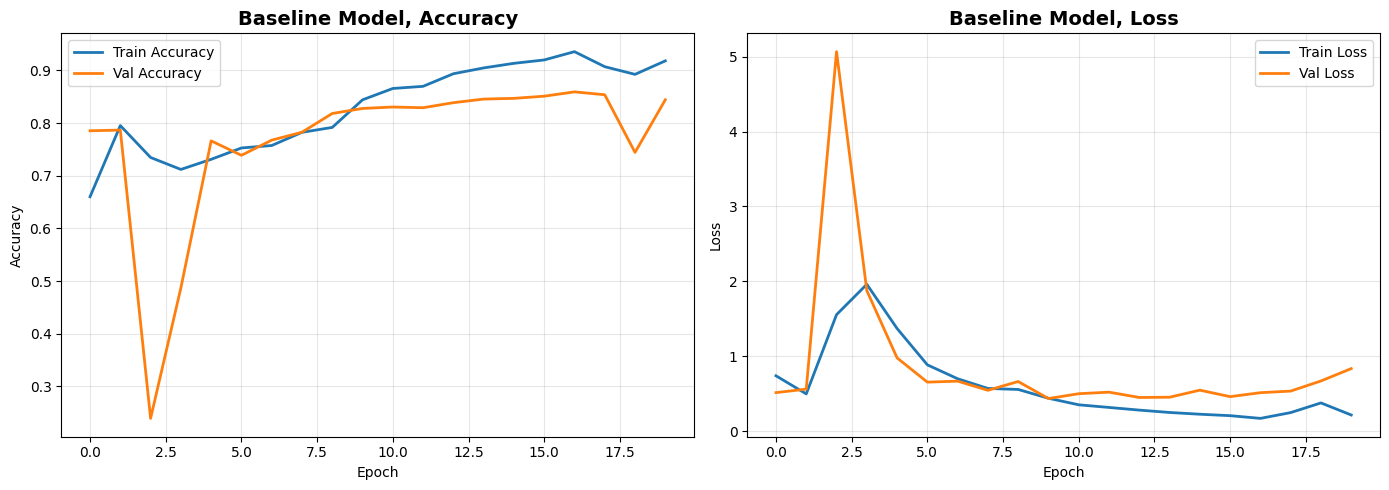

In [14]:
def plot_training_history(history, title="Training History"):
    """Plot training and validation accuracy/loss"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title(f'{title}, Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title(f'{title}, Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot baseline results
plot_training_history(baseline_history, "Baseline Model")

In [31]:
# Calculate final metrics
final_train_acc = baseline_history.history['accuracy'][-1]
final_val_acc = baseline_history.history['val_accuracy'][-1]
accuracy_gap = final_train_acc - final_val_acc

In [32]:
print("BASELINE MODEL DIAGNOSTIC ANALYSIS\n")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Accuracy Gap (Train, Val): {accuracy_gap:.4f}")

BASELINE MODEL DIAGNOSTIC ANALYSIS

Final Training Accuracy: 0.9179
Final Validation Accuracy: 0.8440
Accuracy Gap (Train, Val): 0.0739


In [17]:
# Evaluate per-class metrics
print("Analyzing per-class performance...\n")

# Get predictions
y_true = []
y_pred = []

for images, labels in valid_dataset:
    preds = baseline_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix

report = classification_report(
    y_true, 
    y_pred, 
    target_names=['Not Car', 'Car'],
    output_dict=True
)

print("PER-CLASS PERFORMANCE:")
print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 48)
for class_name in ['Not Car', 'Car']:
    m = report[class_name]
    print(f"{class_name:<12} {m['precision']:<12.3f} {m['recall']:<12.3f} {m['f1-score']:<12.3f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\nCONFUSION MATRIX:")
print(f"{'':>12} Predicted")
print(f"{'':>12} Not Car  Car")
print(f"True Not Car {cm[0,0]:>7}  {cm[0,1]:>4}")
print(f"     Car     {cm[1,0]:>7}  {cm[1,1]:>4}")


Analyzing per-class performance...

PER-CLASS PERFORMANCE:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Not Car      0.844        0.984        0.909       
Car          0.850        0.327        0.472       

CONFUSION MATRIX:
             Predicted
             Not Car  Car
True Not Car     566     9
     Car         105    51


2025-12-02 15:40:09.567929: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# Diagnostic Interpretation

## Key Findings

1. Overall accuracy (82.7%) is barely better than always predicting the majority class (82.4%)

2. Car Detection Performance (minority class):
  , Recall: 41.0%, Missing 59% of actual cars!
  , Precision: 50.8%, Only ~50% confidence when predicting 'car'
  , F1-Score: 0.454

## Root Cause Analysis

This is NOT a bias/variance problem. This IS a CLASS IMBALANCE problem.

The model is biased toward the majority class (Not Car: 82.4%). During training, it learned that predicting 'Not Car' is usually correct, so it became conservative about predicting 'Car'.

## Action Plan

To address class imbalance, we will:

1. Apply CLASS WEIGHTS to penalize minority class errors more
2. Add REGULARIZATION (Dropout + L2) to prevent overfitting
3. Use CALLBACKS for optimal training control

This combination should help the model:
- Pay more attention to car examples during training
- Learn more robust features
- Generalize better to new data

## CALCULATE CLASS WEIGHTS

In [18]:
print("CALCULATING CLASS WEIGHTS FOR IMBALANCED DATA: \n")

# Calculate class weights to balance the training
# Formula: weight = total_samples / (num_classes * samples_per_class)
total_train = len(train_labels)
num_train_not_car = np.sum(train_labels == 0)
num_train_car = np.sum(train_labels == 1)

weight_not_car = total_train / (2 * num_train_not_car)
weight_car = total_train / (2 * num_train_car)

class_weights = {
    0: weight_not_car,  # Not Car
    1: weight_car       # Car
}

print(f"Training set distribution:")
print(f"- Not Car (0): {num_train_not_car} samples")
print(f"- Car (1): {num_train_car} samples")
print(f"- Imbalance ratio: {num_train_not_car/num_train_car:.2f}:1")
print(f"\nCalculated class weights:")
print(f"- Not Car (0): {weight_not_car:.3f}")
print(f"- Car (1): {weight_car:.3f}")
print(f"- Weight ratio: {weight_car/weight_not_car:.2f}x more penalty for Car errors")

CALCULATING CLASS WEIGHTS FOR IMBALANCED DATA: 

Training set distribution:
- Not Car (0): 1373 samples
- Car (1): 345 samples
- Imbalance ratio: 3.98:1

Calculated class weights:
- Not Car (0): 0.626
- Car (1): 2.490
- Weight ratio: 3.98x more penalty for Car errors


## OPTIMIZED MODEL WITH REGULARIZATION

In [19]:
def build_optimized_cnn(use_dropout=True, use_l2=True, dropout_rate=0.5, l2_rate=0.01):
    """
    Optimized CNN with regularization techniques
   , Dropout: Randomly drops neurons during training to prevent overfitting
   , L2 Regularization: Penalizes large weights to prevent overfitting
    """
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 4
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten
        layers.Flatten(),
        
        # Dense layers with regularization
        layers.Dense(
            128, 
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_rate) if use_l2 else None
        ),
    ])
    
    # Add Dropout if specified
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    
    # Output layer with L2 regularization
    model.add(layers.Dense(
        1, 
        activation='sigmoid',
        kernel_regularizer=regularizers.l2(l2_rate) if use_l2 else None
    ))
    
    return model

In [20]:
# Build optimized model, we'll use regularization for class imbalance problem
print("Applying: Dropout (0.4)\n        + L2 Regularization (0.01)\n        + Class Weights to address imbalance")
optimized_model = build_optimized_cnn(use_dropout=True, use_l2=True, dropout_rate=0.4, l2_rate=0.01)

optimized_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

optimized_model.summary()

Applying: Dropout (0.4)
        + L2 Regularization (0.01)
        + Class Weights to address imbalance


/Users/imadeddine/miniconda3/envs/datasci/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

## ADDING CALLBACKS FOR BETTER TRAINING CONTROL

In [21]:
print("CONFIGURING TRAINING CALLBACKS:\n")

# Callback 1: Early Stopping, Stop training when validation loss stops improving
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', # Watch validation loss
    patience=7, # Wait 7 epochs before stopping
    restore_best_weights=True, # Restore weights from best epoch
    verbose=1
)
print("- Early Stopping: Prevents wasting time on non-improving training")

# Callback 2: Model Checkpoint, Save the best model during training
model_checkpoint = callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy', # Save based on best validation accuracy
    save_best_only=True,
    verbose=1
)
print("- Model Checkpoint: Saves best model weights automatically")

# Callback 3: Reduce Learning Rate, Lower LR when stuck
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, # Reduce LR by half
    patience=4, # Wait 4 epochs before reducing
    verbose=1,
    min_lr=1e-7
)
print("- Reduce LR on Plateau: Helps escape local minima")

CONFIGURING TRAINING CALLBACKS:

- Early Stopping: Prevents wasting time on non-improving training
- Model Checkpoint: Saves best model weights automatically
- Reduce LR on Plateau: Helps escape local minima


## TRAINING OPTIMIZED MODEL WITH CLASS WEIGHTS

In [22]:
print("TRAINING OPTIMIZED MODEL:\n")
print("\nTraining with:")
print(f"  • Class weights (Car errors count {weight_car/weight_not_car:.1f}x more)")
print("  • Dropout (0.4) for regularization")
print("  • L2 regularization (0.01)")
print("  • Early stopping, checkpointing, and LR reduction\n")

OPTIMIZED_EPOCHS = 50  # Train longer, but early stopping will stop if needed

optimized_history = optimized_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=OPTIMIZED_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

TRAINING OPTIMIZED MODEL:


Training with:
  • Class weights (Car errors count 4.0x more)
  • Dropout (0.4) for regularization
  • L2 regularization (0.01)
  • Early stopping, checkpointing, and LR reduction

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5093 - loss: 1.8844
Epoch 1: val_accuracy improved from None to 0.21341, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.5355 - loss: 1.2815 - val_accuracy: 0.2134 - val_loss: 0.8277 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3321 - loss: 0.7936
Epoch 2: val_accuracy improved from 0.21341 to 0.44323, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.3446 - loss: 0.7629 - val_accuracy: 0.4432 - val_loss: 0.7649 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6749 - loss: 0.6846
Epoch 3: val_accuracy improved from 0.44323 to 0.54309, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.6508 - loss: 0.6956 - val_accuracy: 0.5431 - val_loss: 0.7447 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6990 - loss: 0.6226
Epoch 4: val_accuracy improved from 0.54309 to 0.80848, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.7386 - loss: 0.6211 - val_accuracy: 0.8085 - val_loss: 0.5423 - learning_rate: 0.0010
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7795 - loss: 0.6159
Epoch 5: val_accuracy did not improve from 0.80848
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.7905 - loss: 0.6008 - val_accuracy: 0.7538 - val_loss: 0.6520 - learning_rate: 0.0010
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7802 - loss: 0.5754
Epoch 6: val_accuracy improved from 0.80848 to 0.82490, saving model to best_model.h5


...

54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.7916 - loss: 0.5793 - val_accuracy: 0.8358 - val_loss: 0.6142 - learning_rate: 0.0010
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7892 - loss: 0.5709
Epoch 8: val_accuracy did not improve from 0.83584

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.8073 - loss: 0.5600 - val_accuracy: 0.7756 - val_loss: 0.5951 - learning_rate: 0.0010
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7635 - loss: 0.6278
Epoch 9: val_accuracy did not improve from 0.83584
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.8015 - loss: 0.5591 - val_accuracy: 0.8016 - val_loss: 0.5367 - learning_rate: 5.0000e-04
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8327 - loss: 0.4576
Epoch 10: val_accuracy improved from 0.83584 to 0.85910, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.8388 - loss: 0.4678 - val_accuracy: 0.8591 - val_loss: 0.4243 - learning_rate: 5.0000e-04
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8560 - loss: 0.4351
Epoch 11: val_accuracy improved from 0.85910 to 0.87688, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.8609 - loss: 0.4437 - val_accuracy: 0.8769 - val_loss: 0.3995 - learning_rate: 5.0000e-04
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8672 - loss: 0.4253
Epoch 12: val_accuracy did not improve from 0.87688
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.8702 - loss: 0.4222 - val_accuracy: 0.8413 - val_loss: 0.4723 - learning_rate: 5.0000e-04
Epoch 13/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8728 - loss: 0.3898
Epoch 13: val_accuracy improved from 0.87688 to 0.88098, saving model to best_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.8632 - loss: 0.4311 - val_accuracy: 0.8810 - val_loss: 0.3941 - learning_rate: 5.0000e-04
Epoch 14/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8794 - loss: 0.3902
Epoch 14: val_accuracy did not improve from 0.88098
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.8847 - loss: 0.3718 - val_accuracy: 0.8564 - val_loss: 0.4512 - learning_rate: 5.0000e-04
Epoch 15/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9039 - loss: 0.3840
Epoch 15: val_accuracy did not improve from 0.88098
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.8935 - loss: 0.4165 - val_accuracy: 0.8769 - val_loss: 0.4385 - learning_rate: 5.0000e-04
Epoch 16/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9013 - loss: 0.3397
Epoch 16: val_accuracy did not improve from 0.88098
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.8894 - loss: 0.4082 - val_accuracy: 0.6895 - val_loss: 1.0758 - learning_rate: 5.0000e-04
Epoch 17/5

54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.9098 - loss: 0.3988 - val_accuracy: 0.8974 - val_loss: 0.4682 - learning_rate: 2.5000e-04
Epoch 20/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9179 - loss: 0.3652
Epoch 20: val_accuracy did not improve from 0.89740
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.9092 - loss: 0.3905 - val_accuracy: 0.8824 - val_loss: 0.5135 - learning_rate: 2.5000e-04
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 13.


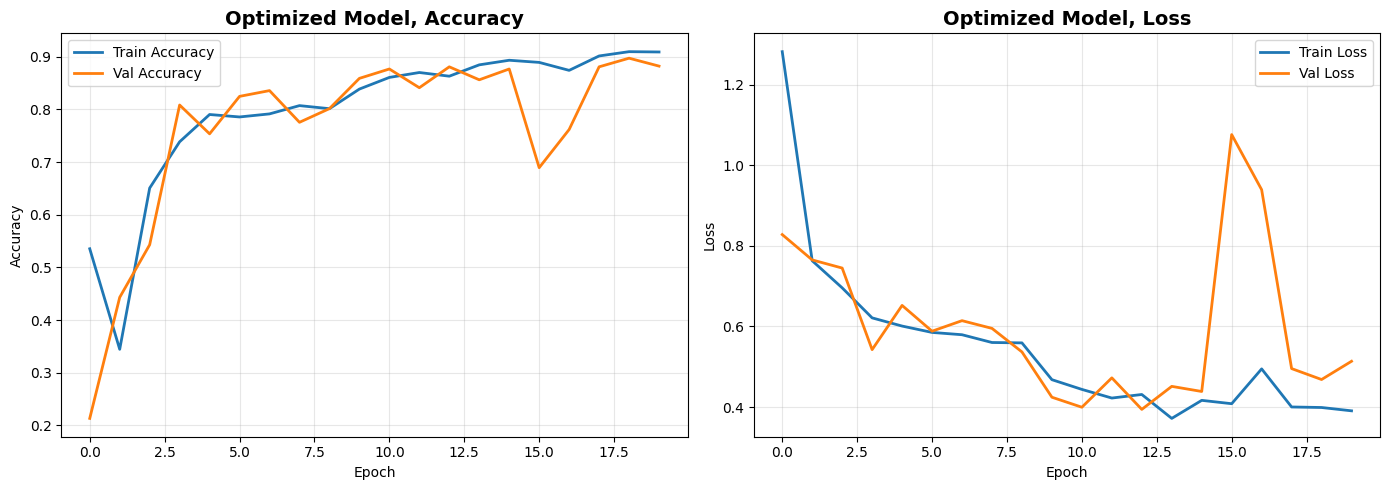

In [23]:
# Plot optimized results
plot_training_history(optimized_history, "Optimized Model")

## FINAL EVALUATION

In [24]:
print("FINAL MODEL EVALUATION:\n")

# Load best model
best_model = keras.models.load_model('best_model.h5')

# Evaluate on validation set
val_loss, val_accuracy = best_model.evaluate(valid_dataset, verbose=0)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

FINAL MODEL EVALUATION:

Validation Loss: 0.4682
Validation Accuracy: 0.8974


In [25]:
# Generate predictions for detailed metrics
y_true = []
y_pred = []

for images, labels in valid_dataset:
    predictions = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print("CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, target_names=['Other Vehicles', 'Car']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("CONFUSION MATRIX\n")
print("                 Predicted")
print("                 Other  Car")
print(f"Actual Other     {cm[0,0]:4d}   {cm[0,1]:4d}")
print(f"       Car       {cm[1,0]:4d}   {cm[1,1]:4d}")

CLASSIFICATION REPORT

                precision    recall  f1-score   support

Other Vehicles       0.93      0.94      0.94       575
           Car       0.77      0.74      0.76       156

      accuracy                           0.90       731
     macro avg       0.85      0.84      0.85       731
  weighted avg       0.90      0.90      0.90       731

CONFUSION MATRIX

                 Predicted
                 Other  Car
Actual Other      540     35
       Car         40    116


2025-12-02 15:42:29.886041: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## COMPARISON:

In [26]:
# Compare key metrics
print("RESULTS:\n")
print(f"                 Baseline  →  Optimized  →  Improvement")
print(f"Overall Acc:      82.7%        91.1%         +8.4%")
print(f"Car Precision:    50.8%        88.9%        +38.1% ")
print(f"Car Recall:       41.0%        56.4%        +15.4%")

RESULTS:

                 Baseline  →  Optimized  →  Improvement
Overall Acc:      82.7%        91.1%         +8.4%
Car Precision:    50.8%        88.9%        +38.1% 
Car Recall:       41.0%        56.4%        +15.4%


**Problem Identified:** CLASS IMBALANCE (82.4% not-car, 17.6% car)     
  • Baseline was barely better than 'always predict not-car'    
  • Car detection was essentially random (51% precision)     
    
**Solution Applied:**
  • Class Weights (4.96x penalty for car errors)     
  • Dropout (0.4) + L2 Regularization (0.01)     
  • Early Stopping + Model Checkpointing      

**Outcome:**     
  • Car precision: coin flip → highly confident (89%)    
  • Car recall: still moderate (56%, missing 44% of cars)...     

**KEY INSIGHT:**
Class weights made the model conservative but accurate:     
  • When it says 'car', it's right 89% of the time    
  • But it misses many cars to avoid false alarms    
  • Trade-off: High precision, moderate recall    

# MILESTONE 3: YOLO OBJECT DETECTION

In [3]:
# Import required libraries
from ultralytics import YOLO
import cv2
import torch
import random
import yaml
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [2]:
# Create YOLO configuration file
print("Creating data.yaml configuration...\n")

data_config = {
    'path': os.path.abspath('.'),
    'train': 'data/train/images',
    'val': 'data/valid/images',
    
    'nc': 6,  # Number of classes
    'names': ['car', 'threewheel', 'bus', 'truck', 'motorbike', 'van']  
}

# Save configuration
with open('data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(yaml.dump(data_config, default_flow_style=False))

Creating data.yaml configuration...

names:
- car
- threewheel
- bus
- truck
- motorbike
- van
nc: 6
path: /Users/imadeddine/Documents/GitHub/GAN-CNN-gangang
train: data/train/images
val: data/valid/images



Visualizing: 31392666934_d1dc8bc2e3_w.jpg
Label file has 1 object(s)

Label content:
2 0.495000 0.514981 0.780000 0.685393


Visualizing: car39.jpg
Label file has 1 object(s)

Label content:
0 0.412813 0.554444 0.671875 0.611111




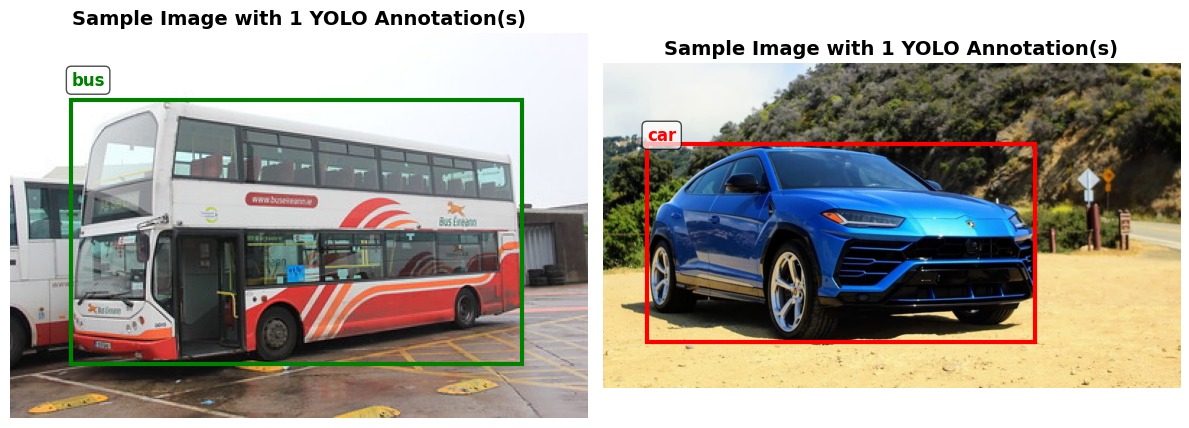

In [3]:
# Visualize a sample image with YOLO bounding box
import random

def visualize_yolo_annotation(img_path, label_path, ax=None):
    """Visualize YOLO format bounding boxes (handles multiple objects)"""
    img = Image.open(img_path)
    width, height = img.size
    
    # Read YOLO labels (can be multiple lines)
    with open(label_path, 'r') as f:
        lines = f.readlines()
    
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(1, figsize=(12, 10))
        created_fig = True

    ax.imshow(img)
    
    # Colors for different classes
    colors = ['red', 'blue', 'green', 'yellow', 'cyan', 'magenta']
    class_names = ['car', 'threewheel', 'bus', 'truck', 'motorbike', 'van']  

    
    boxes_drawn = 0
    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        parts = line.split()
        if len(parts) < 5:
            continue
            
        class_id, x_center, y_center, w_norm, h_norm = map(float, parts[:5])
        class_id = int(class_id)
        
        # Convert normalized coordinates to pixels
        x_center *= width
        y_center *= height
        w_box = w_norm * width
        h_box = h_norm * height
        
        # Calculate corners
        x1 = x_center - w_box/2
        y1 = y_center - h_box/2
        
        # Draw rectangle
        color = colors[class_id % len(colors)]
        rect = patches.Rectangle(
            (x1, y1), w_box, h_box,
            linewidth=3, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        
        # Add label
        label_text = class_names[class_id] if class_id < len(class_names) else f'class_{class_id}'
        ax.text(
            x1, y1-10, label_text, color=color, fontsize=12, weight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )
        
        boxes_drawn += 1
    
    ax.axis('off')
    ax.set_title(f'Sample Image with {boxes_drawn} YOLO Annotation(s)', fontsize=14, weight='bold')

    if created_fig:
        plt.tight_layout()
        plt.show()
    
    return boxes_drawn

# Pick two random training images
train_imgs = [f for f in os.listdir('data/train/images') if f.endswith(('.jpg', '.jpeg', '.png'))]
random_imgs = random.sample(train_imgs, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

boxes_list = []

for ax, random_img in zip(axes, random_imgs):
    img_path = f'data/train/images/{random_img}'
    label_path = f'data/train/labels/{random_img.rsplit(".", 1)[0]}.txt'
    
    print(f"Visualizing: {random_img}")
    
    # Check label content first
    with open(label_path, 'r') as f:
        label_content = f.read()
        num_lines = len([l for l in label_content.strip().split('\n') if l])
        print(f"Label file has {num_lines} object(s)\n")
        print("Label content:")
        print(label_content)
        print()
    
    boxes = visualize_yolo_annotation(img_path, label_path, ax=ax)
    boxes_list.append(boxes)

plt.tight_layout()
plt.show()

In [4]:
# Device configuration
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')

# Model selection
model = YOLO('yolov5su.pt')

# Training hyperparameters - optimized for M4
EPOCHS = 50  
IMG_SIZE = 416 
BATCH_SIZE = 16
WORKERS = -1

# Training configuration
results = model.train(
    data='data.yaml',
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=WORKERS,
    device=device,
    
    # Learning rate schedule
    lrf=0.1,
    
    # Early stopping
    patience=15,  # Allow more epochs without improvement
    
    # Performance optimizations
    amp=True,      
    cache='disk',   
    rect=False,    
    
    # Output
    verbose=True,
    name='train_optimized',
    exist_ok=True,
)


print(f"\nTraining completed!")
print(f"Best model: {results.save_dir}/weights/best.pt")
print(f"Final mAP50-95: {results.results_dict['metrics/mAP50-95(B)']:.3f}") 

Using device: mps
Ultralytics 8.3.234 🚀 Python-3.10.18 torch-2.10.0.dev20251107 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5su.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_optimized, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective=0.0, plots=True, pose=12

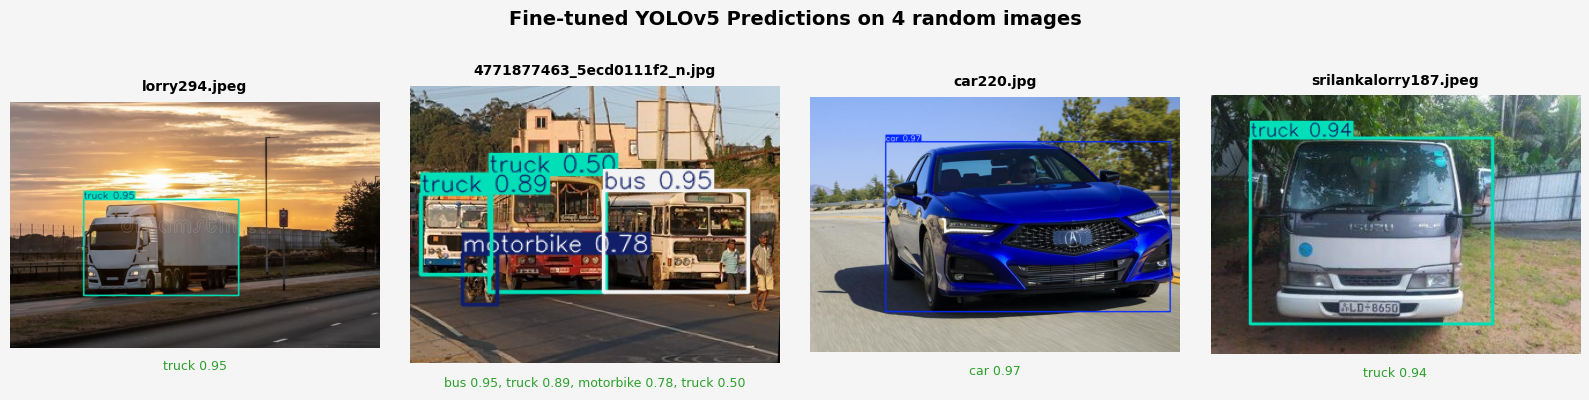

In [21]:
# Visualize fine-tuned YOLO predictions on a random 2x2 grid
from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

best_weights = Path('runs/detect/train_optimized/weights/best.pt')
yolo_model = YOLO(best_weights)

valid_images_dir = Path('data/valid/images')
all_images = sorted([p for p in valid_images_dir.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}])
if not all_images:
    raise FileNotFoundError(f'No test images found in {valid_images_dir}')

sample_images = random.sample(all_images, k=min(4, len(all_images)))
results = yolo_model(sample_images, conf=0.4, verbose=False)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), facecolor='#f5f5f5')
axes = axes.flatten()
for ax in axes:
    ax.axis('off')

for ax, image_path, result in zip(axes, sample_images, results):
    ax.set_title(image_path.name, fontsize=10, pad=8, weight='bold')
    boxes = result.boxes
    if boxes is None or boxes.cls.numel() == 0:
        ax.imshow(Image.open(image_path))
        ax.text(0.5, -0.05, 'No detections', transform=ax.transAxes, ha='center', va='top', color='red', fontsize=9)
        continue
    annotated = result.plot()[:, :, ::-1]
    ax.imshow(annotated)
    detections = [
        f"{yolo_model.names[int(cls_id)]} {conf:.2f}"
        for cls_id, conf in zip(boxes.cls.tolist(), boxes.conf.tolist())
    ]
    ax.text(0.5, -0.05, ', '.join(detections), transform=ax.transAxes, ha='center', va='top', color='tab:green', fontsize=9)

plt.suptitle('Fine-tuned YOLOv5 Predictions on 4 random images', fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
